# POMDP Candidate Selector

Notebook-first inspection of the first belief-limited attacker selector.

This is not a trained policy yet. It ranks VAE candidates using noisy attacker observations and profile/intent metadata, then compares that ranking to the full-state Monte Carlo selector when ranked-candidate artifacts are available.


## Imports


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve repo root when this notebook is launched from either repo root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "convoy_sim").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from convoy_sim.feasibility import Environment
from convoy_sim.pomdp_candidate_selector import (
    build_candidate_observation_rows,
    rank_candidate_observation_rows,
    write_belief_ranked_csv,
    write_belief_ranked_json,
)
from convoy_sim.profile_generation_viz import FIXED_X_LIMITS, apply_limits, combined_limits, simple_ship_polygons, style_ax
from convoy_sim.realism import get_attacker_observation_config
from experiments.evaluate_attack_candidate_pool import load_candidate_records
from scenarios.convoy_profiles import get_convoy_layout_profile

PROJECT_ROOT


PosixPath('/Users/matthewplambeck/Desktop/Convoy Layout Project')

## Config


In [2]:
CANDIDATE_PATH = Path("data/attack_profiles/vae_candidates/mixed_curated70_random30_hit_candidates.jsonl")
FULL_STATE_RANKED_CSV = Path("results/runs/candidate_pool_eval/20260511_211859_vae_source_compare_mixed_70_30/ranked_candidates.csv")
CONVOY_PROFILE = "convoy_layout_1"
MAX_PROFILES = 100
TOP_K = 25
SEED = 1945

OBSERVATION_PRESET = "good_contact"
OBS_CFG = get_attacker_observation_config(OBSERVATION_PRESET)
ENV = Environment(time_of_day="night", visibility_m=3500.0, sea_state=4)

OUTPUT_DIR = PROJECT_ROOT / "results" / "diag" / "pomdp_candidate_selector"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Build Belief-Limited Ranking


In [3]:
records_all = load_candidate_records(PROJECT_ROOT / CANDIDATE_PATH)
records = records_all[: int(MAX_PROFILES)] if MAX_PROFILES is not None else records_all
ships = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()

observation_rows = build_candidate_observation_rows(
    records,
    ships=ships,
    seed=int(SEED),
    env=ENV,
    observation_cfg=OBS_CFG,
)
ranked_rows = rank_candidate_observation_rows(observation_rows)

belief_df = pd.DataFrame(ranked_rows)
write_belief_ranked_csv(OUTPUT_DIR / "belief_ranked_candidates.csv", ranked_rows)
write_belief_ranked_json(OUTPUT_DIR / "top_belief_candidates.json", ranked_rows[: int(TOP_K)])
belief_df.head(10)


,profile_id,name,belief_score,u_pos_x,u_pos_y,estimated_range_m,estimated_bearing_rad,estimated_convoy_heading_rad,estimated_convoy_speed_mps,estimated_contact_count,...,spawn_region,approach_side,inside_convoy_envelope,spread_rad,launch_delay_s,salvo_interval_s,u_boat_initial_speed_mps,candidate_source_label,selector_method,belief_rank
0,VAE000009,vae_candidate_000009,1.031639,154.159698,-2216.000000,2276.640546,1.653399,-0.008811,5.085192,42,...,inside_convoy_envelope,inside,True,0.047894,2.276132,2.054655,1.583893,vae_candidate_pool_v1,belief_limited_heuristic_v1,1
1,VAE000012,vae_candidate_000012,1.027994,-72.925690,2110.332764,2109.772883,-1.570221,0.033186,4.795856,42,...,inside_convoy_envelope,inside,True,0.060888,0.773117,1.515693,1.799757,vae_candidate_pool_v1,belief_limited_heuristic_v1,2
2,VAE000119,vae_candidate_000119,1.017345,-348.427734,-1952.292969,2021.811972,1.361763,0.011141,4.491224,42,...,inside_convoy_envelope,inside,True,0.047844,1.683568,2.462964,1.365952,vae_candidate_pool_v1,belief_limited_heuristic_v1,3
3,VAE000126,vae_candidate_000126,1.014957,10.926025,-1917.536621,1832.361581,1.530874,0.039410,4.573926,42,...,inside_convoy_envelope,inside,True,0.048780,1.576117,2.478103,1.148087,vae_candidate_pool_v1,belief_limited_heuristic_v1,4
4,VAE000123,vae_candidate_000123,1.007708,-420.316101,-1652.519409,1836.758394,1.339639,-0.016616,5.180991,42,...,inside_convoy_envelope,inside,True,0.050740,1.825867,2.529837,1.096498,vae_candidate_pool_v1,belief_limited_heuristic_v1,5
5,VAE000098,vae_candidate_000098,1.001944,-207.563660,-3097.954834,3063.608716,1.532288,-0.034027,4.503830,42,...,inside_convoy_envelope,inside,True,0.051210,1.710977,2.007589,1.817544,vae_candidate_pool_v1,belief_limited_heuristic_v1,6
6,VAE000089,vae_candidate_000089,0.970376,1269.649536,2517.448486,2691.990453,-2.011584,-0.065932,4.726425,42,...,ahead_vae,ahead,False,0.064042,2.364845,1.971598,1.523588,vae_candidate_pool_v1,belief_limited_heuristic_v1,7
7,VAE000054,vae_candidate_000054,0.963561,-1082.787109,3302.584473,3424.971530,-1.219259,-0.032880,5.041834,42,...,inside_convoy_envelope,inside,True,0.062386,1.453894,1.498346,1.493991,vae_candidate_pool_v1,belief_limited_heuristic_v1,8
8,VAE000111,vae_candidate_000111,0.958578,-464.637024,-3562.217041,3700.223034,1.460556,0.049091,5.615648,42,...,inside_convoy_envelope,inside,True,0.075974,2.030167,2.520100,1.221301,vae_candidate_pool_v1,belief_limited_heuristic_v1,9
9,VAE000063,vae_candidate_000063,0.951521,-1379.863525,-1766.912476,2261.456330,0.897034,-0.014483,5.057126,42,...,astern_vae,astern,False,0.067833,1.379872,1.510480,1.221248,vae_candidate_pool_v1,belief_limited_heuristic_v1,10


## Summary


In [4]:
summary = {
    "candidate_path": str(PROJECT_ROOT / CANDIDATE_PATH),
    "profiles_ranked": int(len(belief_df)),
    "top_k": int(TOP_K),
    "best_profile_id": str(belief_df.iloc[0]["profile_id"]) if len(belief_df) else "",
    "best_belief_score": float(belief_df.iloc[0]["belief_score"]) if len(belief_df) else np.nan,
    "mean_belief_score": float(belief_df["belief_score"].mean()) if len(belief_df) else np.nan,
    "observation_preset": OBSERVATION_PRESET,
    "observation_config": OBS_CFG.to_dict(),
}
(OUTPUT_DIR / "belief_summary.json").write_text(json.dumps(summary, indent=2) + "\n", encoding="utf-8")
summary


{'candidate_path': '/Users/matthewplambeck/Desktop/Convoy Layout Project/data/attack_profiles/vae_candidates/mixed_curated70_random30_hit_candidates.jsonl',
 'profiles_ranked': 100,
 'top_k': 25,
 'best_profile_id': 'VAE000009',
 'best_belief_score': 1.0316393580370653,
 'mean_belief_score': 0.7910191797544273,
 'observation_preset': 'good_contact',
 'observation_config': {'bearing_sigma_rad': 0.025,
  'range_sigma_m': 80.0,
  'heading_sigma_rad': 0.035,
  'speed_sigma_mps': 0.3,
  'contact_count_sigma': 0.25,
  'formation_width_sigma_m': 100.0,
  'formation_depth_sigma_m': 120.0,
  'class_count_sigma': 0.5}}

## Belief Feature Diagnostics


In [5]:
display_cols = [
    "belief_rank",
    "profile_id",
    "belief_score",
    "estimated_range_m",
    "bearing_alignment_score",
    "aspect_score",
    "spread_score",
    "inside_score",
    "uncertainty_score",
    "spawn_region",
    "approach_side",
]
belief_df[display_cols].head(int(TOP_K))


,belief_rank,profile_id,belief_score,estimated_range_m,bearing_alignment_score,aspect_score,spread_score,inside_score,uncertainty_score,spawn_region,approach_side
0,1,VAE000009,1.031639,2276.640546,0.997814,0.995825,0.815820,1.0,0.076555,inside_convoy_envelope,inside
1,2,VAE000012,1.027994,2109.772883,0.962117,0.999468,0.912679,1.0,0.075031,inside_convoy_envelope,inside
2,3,VAE000119,1.017345,2021.811972,0.986986,0.975859,0.815397,1.0,0.078720,inside_convoy_envelope,inside
3,4,VAE000126,1.014957,1832.361581,0.997241,0.996855,0.823247,1.0,0.081530,inside_convoy_envelope,inside
4,5,VAE000123,1.007708,1836.758394,0.978272,0.977074,0.839290,1.0,0.080057,inside_convoy_envelope,inside
5,6,VAE000098,1.001944,3063.608716,0.960025,0.999990,0.843060,1.0,0.069819,inside_convoy_envelope,inside
6,7,VAE000089,0.970376,2691.990453,0.972039,0.930561,0.931622,0.0,0.075577,ahead_vae,ahead
7,8,VAE000054,0.963561,3424.971530,0.950943,0.927017,0.921929,1.0,0.070246,inside_convoy_envelope,inside
8,9,VAE000111,0.958578,3700.223034,0.969357,0.987334,0.983395,1.0,0.069187,inside_convoy_envelope,inside
9,10,VAE000063,0.951521,2261.456330,0.990510,0.790434,0.951618,0.0,0.074935,astern_vae,astern


In [6]:
component_cols = ["range_score", "bearing_alignment_score", "aspect_score", "spread_score", "contact_score", "inside_score", "uncertainty_score"]
component_summary = belief_df[component_cols].describe().T
component_summary.to_csv(OUTPUT_DIR / "belief_component_summary.csv")
component_summary


,count,mean,std,min,25%,50%,75%,max
range_score,100.0,0.496916,0.370530,0.000019,0.112139,0.433277,0.899830,0.999813
bearing_alignment_score,100.0,0.935056,0.170759,0.004548,0.957105,0.975403,0.993384,0.999999
aspect_score,100.0,0.775045,0.269972,0.009011,0.628444,0.903096,0.984608,0.999990
spread_score,100.0,0.922809,0.073506,0.681528,0.865431,0.953827,0.987840,1.000000
contact_score,100.0,0.999762,0.002381,0.976190,1.000000,1.000000,1.000000,1.000000
inside_score,100.0,0.180000,0.386123,0.000000,0.000000,0.000000,0.000000,1.000000
uncertainty_score,100.0,0.074253,0.016121,0.063620,0.068027,0.069622,0.074498,0.199732


## Compare To Full-State Ranking


In [7]:
if (PROJECT_ROOT / FULL_STATE_RANKED_CSV).exists():
    full_state_df = pd.read_csv(PROJECT_ROOT / FULL_STATE_RANKED_CSV)
    compare_df = belief_df.merge(
        full_state_df[["profile_id", "rank", "attacker_score", "expected_loss", "expected_hits", "expected_unique_ships_hit", "value_lost"]],
        on="profile_id",
        how="left",
        suffixes=("_belief", "_full_state"),
    )
    compare_df = compare_df.rename(columns={"rank": "full_state_rank"})
    compare_df["in_full_state_top_k"] = compare_df["full_state_rank"].le(int(TOP_K))
    compare_df["in_belief_top_k"] = compare_df["belief_rank"].le(int(TOP_K))
    overlap = int((compare_df["in_full_state_top_k"] & compare_df["in_belief_top_k"]).sum())
    comparison_summary = {
        "belief_top_k": int(TOP_K),
        "full_state_top_k": int(TOP_K),
        "top_k_overlap": overlap,
        "top_k_overlap_rate": float(overlap / max(int(TOP_K), 1)),
        "belief_best_profile_id": str(compare_df.sort_values("belief_rank").iloc[0]["profile_id"]),
        "full_state_best_profile_id": str(full_state_df.sort_values("rank").iloc[0]["profile_id"]),
    }
    compare_df.to_csv(OUTPUT_DIR / "belief_vs_full_state_ranked.csv", index=False)
    (OUTPUT_DIR / "belief_vs_full_state_summary.json").write_text(json.dumps(comparison_summary, indent=2) + "\n", encoding="utf-8")
else:
    full_state_df = pd.DataFrame()
    compare_df = belief_df.copy()
    comparison_summary = {"warning": f"Missing full-state ranked CSV: {PROJECT_ROOT / FULL_STATE_RANKED_CSV}"}
comparison_summary


{'belief_top_k': 25,
 'full_state_top_k': 25,
 'top_k_overlap': 2,
 'top_k_overlap_rate': 0.08,
 'belief_best_profile_id': 'VAE000009',
 'full_state_best_profile_id': 'VAE000124'}

In [8]:
if "full_state_rank" in compare_df.columns:
    compare_df[[
        "belief_rank",
        "full_state_rank",
        "profile_id",
        "belief_score",
        "expected_loss",
        "expected_hits",
        "expected_unique_ships_hit",
        "spawn_region",
    ]].sort_values("belief_rank").head(int(TOP_K))


## Plots


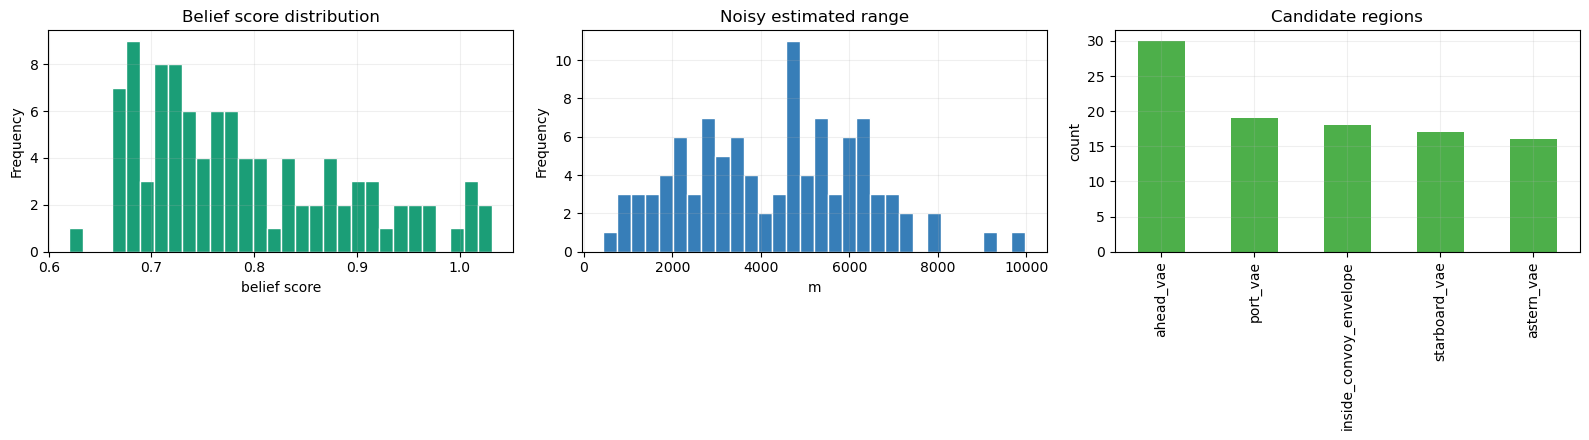

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), facecolor="white")

belief_df["belief_score"].plot.hist(ax=axes[0], bins=30, color="#1b9e77", edgecolor="white")
axes[0].set_title("Belief score distribution")
axes[0].set_xlabel("belief score")

belief_df["estimated_range_m"].plot.hist(ax=axes[1], bins=30, color="#377eb8", edgecolor="white")
axes[1].set_title("Noisy estimated range")
axes[1].set_xlabel("m")

belief_df["spawn_region"].value_counts().plot.bar(ax=axes[2], color="#4daf4a")
axes[2].set_title("Candidate regions")
axes[2].set_xlabel("")
axes[2].set_ylabel("count")

for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


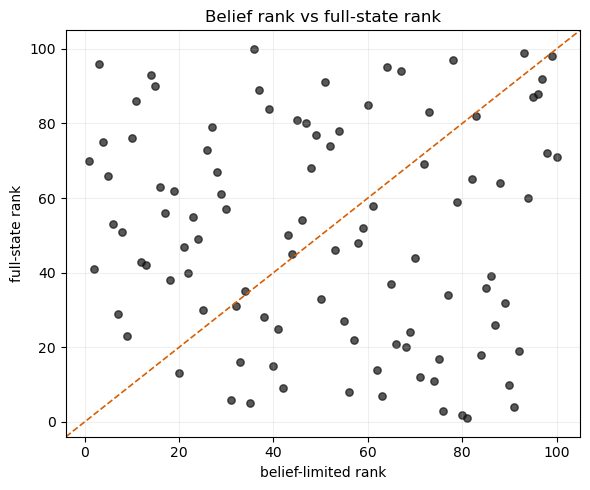

In [10]:
if "full_state_rank" in compare_df.columns:
    fig, ax = plt.subplots(figsize=(6, 5), facecolor="white")
    plot_df = compare_df.dropna(subset=["full_state_rank"])
    ax.scatter(plot_df["belief_rank"], plot_df["full_state_rank"], s=28, alpha=0.7, color="#111111")
    ax.axline((1, 1), slope=1, color="#d95f02", linestyle="--", linewidth=1.2)
    ax.set_title("Belief rank vs full-state rank")
    ax.set_xlabel("belief-limited rank")
    ax.set_ylabel("full-state rank")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


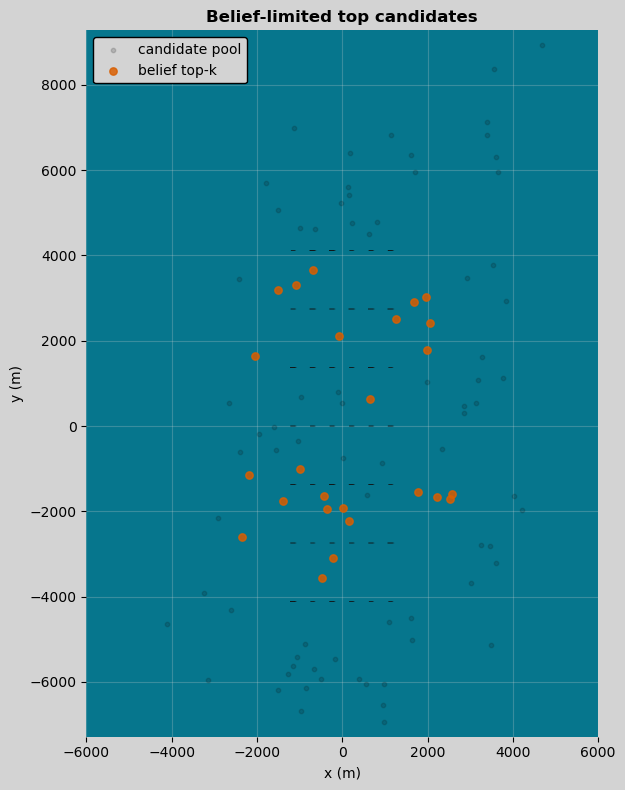

In [11]:
ship_xy = np.asarray([ship.position for ship in ships], dtype=float)
candidate_xy = belief_df[["u_pos_x", "u_pos_y"]].to_numpy(dtype=float) if {"u_pos_x", "u_pos_y"} <= set(belief_df.columns) else None
if candidate_xy is None:
    candidate_xy = np.asarray([record["profile"]["u_pos"] for record in records], dtype=float)
    belief_df["u_pos_x"] = candidate_xy[:, 0]
    belief_df["u_pos_y"] = candidate_xy[:, 1]
limits = combined_limits(ships, extra_points=candidate_xy, pad=350.0)

top_belief = belief_df.head(int(TOP_K)).copy()
fig, ax = plt.subplots(figsize=(10, 8), facecolor="lightgrey")
style_ax(ax, "Belief-limited top candidates")
simple_ship_polygons(ax, ships)
ax.scatter(candidate_xy[:, 0], candidate_xy[:, 1], c="#111111", s=10, alpha=0.16, label="candidate pool", zorder=2)
ax.scatter(top_belief["u_pos_x"], top_belief["u_pos_y"], c="#d95f02", s=28, alpha=0.85, label="belief top-k", zorder=3)
apply_limits(ax, limits, fixed_x_limits=FIXED_X_LIMITS)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.legend(frameon=True, facecolor="lightgrey", edgecolor="black", framealpha=1.0)
plt.tight_layout()
plt.show()


## Artifact Paths


In [12]:
{
    "belief_ranked_candidates_csv": str(OUTPUT_DIR / "belief_ranked_candidates.csv"),
    "top_belief_candidates_json": str(OUTPUT_DIR / "top_belief_candidates.json"),
    "belief_summary_json": str(OUTPUT_DIR / "belief_summary.json"),
    "belief_component_summary_csv": str(OUTPUT_DIR / "belief_component_summary.csv"),
    "belief_vs_full_state_ranked_csv": str(OUTPUT_DIR / "belief_vs_full_state_ranked.csv"),
    "belief_vs_full_state_summary_json": str(OUTPUT_DIR / "belief_vs_full_state_summary.json"),
}


{'belief_ranked_candidates_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_candidate_selector/belief_ranked_candidates.csv',
 'top_belief_candidates_json': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_candidate_selector/top_belief_candidates.json',
 'belief_summary_json': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_candidate_selector/belief_summary.json',
 'belief_component_summary_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_candidate_selector/belief_component_summary.csv',
 'belief_vs_full_state_ranked_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_candidate_selector/belief_vs_full_state_ranked.csv',
 'belief_vs_full_state_summary_json': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_candidate_selector/belief_vs_full_state_summary.json'}